This script analyzes supermarket sales (~9000 rows). 
Key steps:
- Load and clean the dataset
- Convert dates and remove invalid entries
- Analyze sales trends (daily and yearly)
- Compare sales by product category and cities


Import required libraries for data handling and plotting

In [192]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

Load the CSV into a DataFrame and inspect its structure


In [193]:
df=pd.read_csv("supermarket.csv")
print(df.columns)
print(df.shape)

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')
(9994, 11)


Remove columns that are irrelevant for the current analysis

In [194]:
df.drop(columns=['Order ID','Customer Name','Region','State'],inplace=True)
print(df.columns)
print(df.shape)

Index(['Category', 'Sub Category', 'City', 'Order Date', 'Sales', 'Discount',
       'Profit'],
      dtype='object')
(9994, 7)


Drop rows that are missing essential information

In [195]:
df.dropna(subset=['Category', 'Sub Category', 'City', 'Order Date', 'Sales', 'Discount',
       'Profit'],inplace=True)

Convert 'Order Date' to datetime and remove rows with invalid dates

In [196]:
df['Order Date']=pd.to_datetime(df['Order Date'],errors='coerce')
df.dropna(subset='Order Date',inplace=True)

Aggregate daily sales: group by date and compute total sales per day

In [197]:
df2=df[['Order Date','Sales']].copy()
df2=df2.groupby('Order Date',as_index=False)['Sales'].sum()
df2=df2.sort_values(by='Order Date',ascending=True).reset_index(drop=True)

Visualize total daily sales across the dataset

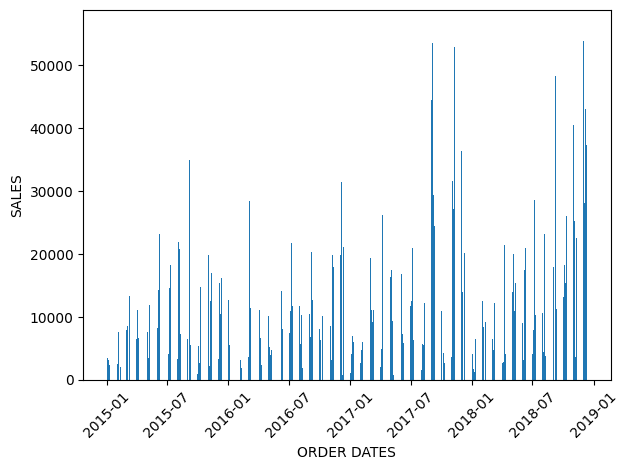

In [198]:
plt.bar(df2['Order Date'],df2['Sales'])
plt.xlabel("ORDER DATES")
plt.ylabel("SALES")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Define a function to compute monthly sales for a given year

In [199]:
def yearly_sales(Year):
    df_yearly=df2[df2['Order Date'].dt.year==Year]
    df_yearly_monthly=df_yearly.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum().reset_index()
    return df_yearly_monthly

Display monthly trend for a specific year (example: 2017)

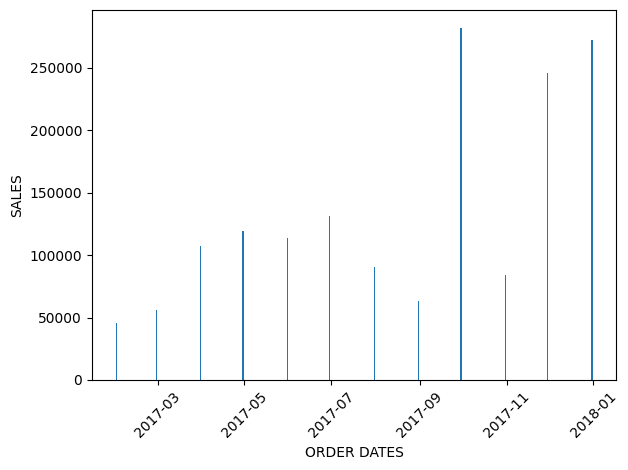

In [200]:
df_yearly_monthly=yearly_sales(2017)
plt.bar(df_yearly_monthly['Order Date'],df_yearly_monthly['Sales'])
plt.xlabel("ORDER DATES")
plt.ylabel("SALES")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Display all available product categories

In [201]:
print(pd.unique(df['Category']))

['Oil & Masala' 'Beverages' 'Food Grains' 'Fruits & Veggies' 'Bakery'
 'Snacks' 'Eggs, Meat & Fish']


Compare total sales for each product category

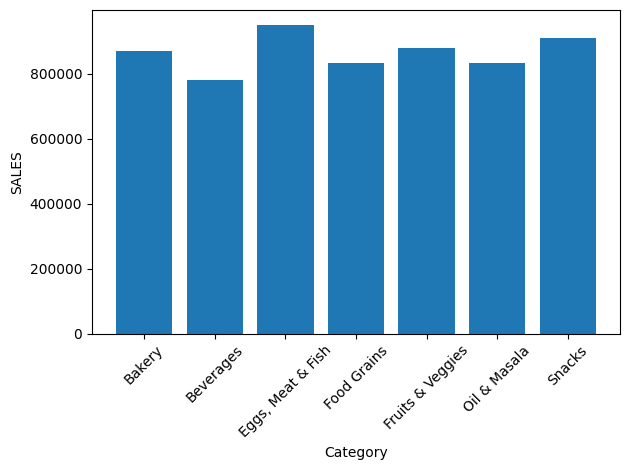

In [202]:
df3=df[['Category','Sales']].copy()
df3=df3.groupby('Category',as_index=False)['Sales'].sum().reset_index(drop=True)
plt.bar(df3['Category'],df3['Sales'])
plt.xlabel("Category")
plt.ylabel("SALES")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Identify and display the top 10 highest-selling cities

In [203]:
top_cities=df[['City','Sales']].copy()
top_cities=top_cities.groupby('City',as_index=False)['Sales'].sum()
top_cities=top_cities.sort_values(by='Sales',ascending=False).reset_index(drop=True)
top_cities=top_cities[:10]


Identify and display the 10 lowest-selling cities

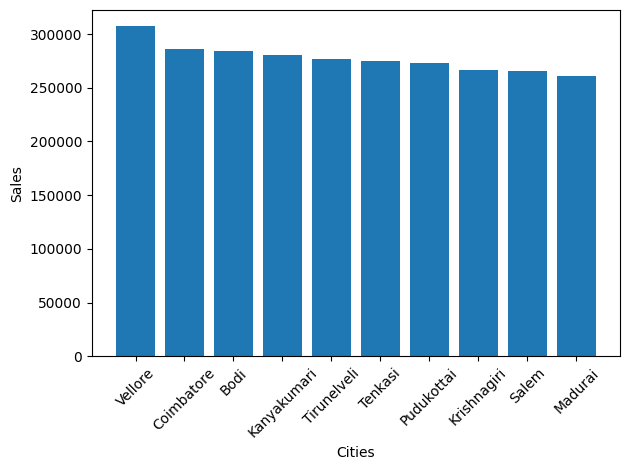

In [204]:
plt.bar(top_cities['City'],top_cities['Sales'])
plt.xlabel("Cities")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bottom performing city on sales

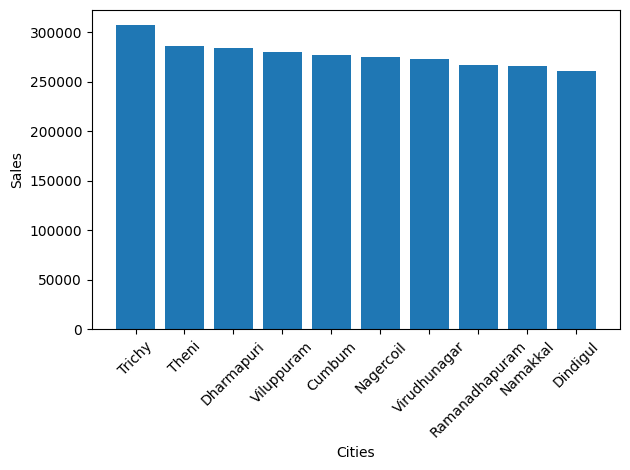

In [205]:
bottom_cities = df.groupby('City', as_index=False)['Sales'].sum().nsmallest(10, 'Sales')
plt.bar(bottom_cities['City'],top_cities['Sales'])
plt.xlabel("Cities")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()